In [ ]:
!pip install -q langgraph langchain-core langchain-openai python-dotenv grandalf

In [2]:
import os
from getpass import getpass

print("🔐 Enter your OpenAI API Key")
api_key = getpass("OpenAI API Key: ")

os.environ["OPENAI_API_KEY"] = api_key

🔐 Enter your OpenAI API Key
OpenAI API Key: ··········


In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",  # or gpt-4o
    temperature=0.7
)

print("✅ OpenAI LLM Initialized")

✅ OpenAI LLM Initialized


### **WORKFLOW 1 — BASIC LINEAR FLOW**

In [4]:
from typing import TypedDict
from datetime import datetime
from langgraph.graph import StateGraph, START, END

class BasicState(TypedDict):
    topic: str
    research: str
    summary: str
    final_output: str


def research_node(state: BasicState):
    response = llm.invoke(f"Give 3 key facts about {state['topic']}")
    return {**state, "research": response.content}


def summarize_node(state: BasicState):
    response = llm.invoke(f"Summarize in 2 sentences: {state['research']}")
    return {**state, "summary": response.content}


def final_output_node(state: BasicState):
    return {
        **state,
        "final_output": f"""
📘 REPORT
Topic: {state['topic']}

Research:
{state['research']}

Summary:
{state['summary']}

Generated: {datetime.now()}
"""
    }


def create_basic_workflow():
    workflow = StateGraph(BasicState)

    workflow.add_node("research", research_node)
    workflow.add_node("summarize", summarize_node)
    workflow.add_node("final_output", final_output_node)

    workflow.add_edge(START, "research")
    workflow.add_edge("research", "summarize")
    workflow.add_edge("summarize", "final_output")
    workflow.add_edge("final_output", END)

    return workflow.compile()

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [5]:
basic_app = create_basic_workflow()

result = basic_app.invoke({
    "topic": "Artificial Intelligence",
    "research": "",
    "summary": "",
    "final_output": ""
})

print(result["final_output"])


📘 REPORT
Topic: Artificial Intelligence

Research:
Here are three key facts about Artificial Intelligence (AI):

1. **Types of AI**: AI is generally classified into two main types: Narrow AI and General AI. Narrow AI, also known as Weak AI, is designed to perform specific tasks, such as language translation or facial recognition. General AI, or Strong AI, refers to a theoretical form of AI that has the ability to understand, learn, and apply intelligence across a wide range of tasks, similar to human cognitive abilities.

2. **Machine Learning**: A significant subset of AI, machine learning involves algorithms that enable computers to learn from and make predictions or decisions based on data. This process often involves training models on large datasets, allowing the AI to improve its performance over time without explicit programming for each task.

3. **Applications Across Industries**: AI is being utilized in various sectors, including healthcare (for diagnostics and personalized 

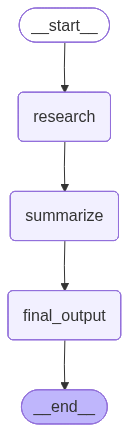

In [6]:
from IPython.display import Image

graph = basic_app.get_graph()
display(Image(graph.draw_mermaid_png()))

### **WORKFLOW 2 — PARALLEL PROCESSING**

In [12]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END

def pick_first_value(a: str, b: str) -> str:
    return a


class ParallelState(TypedDict):
    topic: Annotated[str, pick_first_value]
    research: str
    creative: str
    analysis: str
    final_report: str


def research_node(state: ParallelState):
    res = llm.invoke(f"Research detailed facts about {state['topic']}")
    return {"research": res.content}


def creative_node(state: ParallelState):
    res = llm.invoke(f"Write engaging content about {state['topic']}")
    return {"creative": res.content}


def analysis_node(state: ParallelState):
    res = llm.invoke(f"Analyze pros, cons, and future of {state['topic']}")
    return {"analysis": res.content}


def final_report_node(state: ParallelState):
    return {
        "final_report": f"""
🌍 FINAL REPORT — {state['topic']}

Research:
{state['research'][:300]}

Creative:
{state['creative'][:300]}

Analysis:
{state['analysis'][:300]}
"""
    }


def create_parallel_workflow():
    workflow = StateGraph(ParallelState)

    workflow.add_node("research", research_node)
    workflow.add_node("creative", creative_node)
    workflow.add_node("analysis", analysis_node)
    workflow.add_node("final_report", final_report_node)

    workflow.add_edge(START, "research")

    workflow.add_edge("research", "creative")
    workflow.add_edge("research", "analysis")

    workflow.add_edge("creative", "final_report")
    workflow.add_edge("analysis", "final_report")

    workflow.add_edge("final_report", END)

    return workflow.compile()




In [13]:
parallel_app = create_parallel_workflow()

result = parallel_app.invoke({
    "topic": "Renewable Energy",
    "research": "",
    "creative": "",
    "analysis": "",
    "final_report": ""
})

print(result["final_report"])


🌍 FINAL REPORT — 

Research:
It seems like your request was cut off. Could you please provide more details about the specific topic or subject you would like to research? This will help me assist you better!

Creative:
Of course! It seems like your request got cut off. Could you please provide more details about the topic or subject you'd like the engaging content to focus on? Whether it's a specific theme, product, event, or idea, I'm here to help!

Analysis:
It seems like your request got cut off before you specified the topic you'd like me to analyze the pros, cons, and future of. Could you please clarify what subject or issue you would like me to focus on? Whether it's a technology, policy, business model, or something else entirely, I'm here to help!



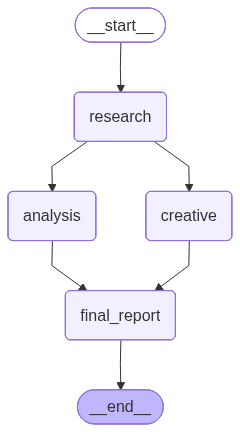

In [ ]:
display(Image(parallel_app.get_graph().draw_mermaid_png()))

### **WORKFLOW 3 — CONDITIONAL BRANCHING**

In [ ]:
class ConditionalState(TypedDict):
    query: str
    query_type: str
    response: str


def classify_node(state: ConditionalState):
    res = llm.invoke(
        f"Classify this as technical, creative, or general: {state['query']}"
    )
    return {**state, "query_type": res.content.strip().lower()}


def technical_node(state):
    res = llm.invoke(f"Provide detailed technical answer: {state['query']}")
    return {**state, "response": res.content}


def creative_node(state):
    res = llm.invoke(f"Provide creative response: {state['query']}")
    return {**state, "response": res.content}


def general_node(state):
    res = llm.invoke(f"Provide clear explanation: {state['query']}")
    return {**state, "response": res.content}


def route(state: ConditionalState):
    if "technical" in state["query_type"]:
        return "technical"
    elif "creative" in state["query_type"]:
        return "creative"
    else:
        return "general"


def create_conditional_workflow():
    workflow = StateGraph(ConditionalState)

    workflow.add_node("classify", classify_node)
    workflow.add_node("technical", technical_node)
    workflow.add_node("creative", creative_node)
    workflow.add_node("general", general_node)

    workflow.add_edge(START, "classify")

    workflow.add_conditional_edges(
        "classify",
        route,
        {
            "technical": "technical",
            "creative": "creative",
            "general": "general"
        }
    )

    workflow.add_edge("technical", END)
    workflow.add_edge("creative", END)
    workflow.add_edge("general", END)

    return workflow.compile()

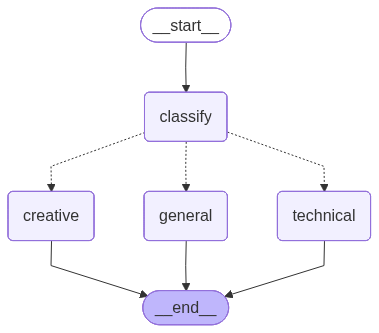

In [ ]:
conditional_app = create_conditional_workflow()
display(Image(conditional_app.get_graph().draw_mermaid_png()))

### **WORKFLOW 4 — LOOP / SELF-IMPROVING AGENT**

In [ ]:
class LoopState(TypedDict):
    query: str
    response: str
    score: int
    iteration: int


def generate_node(state: LoopState):
    res = llm.invoke(f"Answer: {state['query']}")
    return {**state, "response": res.content, "iteration": state["iteration"] + 1}


def evaluate_node(state: LoopState):
    res = llm.invoke(
        f"Score this answer 1-5 only:\n{state['response']}"
    )
    try:
        score = int(res.content.strip()[0])
    except:
        score = 3
    return {**state, "score": score}


def route_loop(state: LoopState):
    if state["score"] < 4 and state["iteration"] < 3:
        return "generate"
    return "end"


def create_loop_workflow():
    workflow = StateGraph(LoopState)

    workflow.add_node("generate", generate_node)
    workflow.add_node("evaluate", evaluate_node)

    workflow.add_edge(START, "generate")
    workflow.add_edge("generate", "evaluate")

    workflow.add_conditional_edges(
        "evaluate",
        route_loop,
        {
            "generate": "generate",
            "end": END
        }
    )

    return workflow.compile()

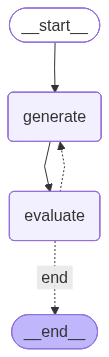

In [ ]:
loop_app = create_loop_workflow()
display(Image(loop_app.get_graph().draw_mermaid_png()))